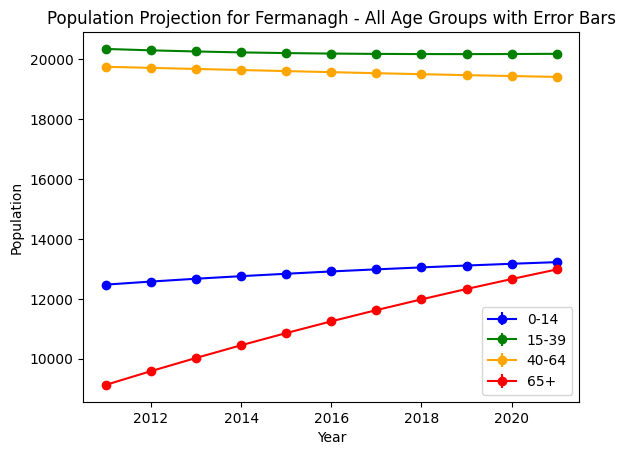

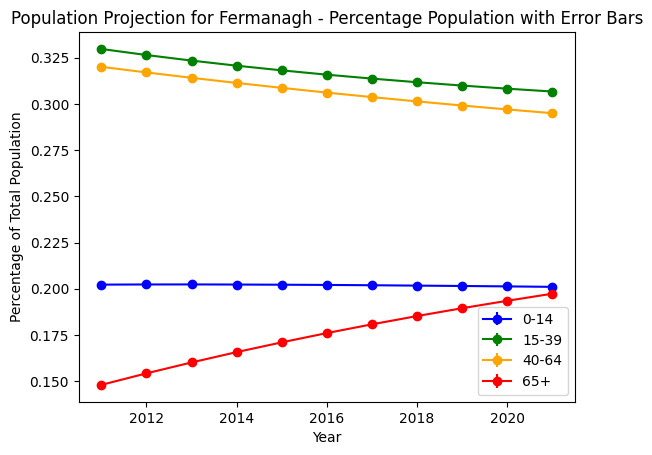

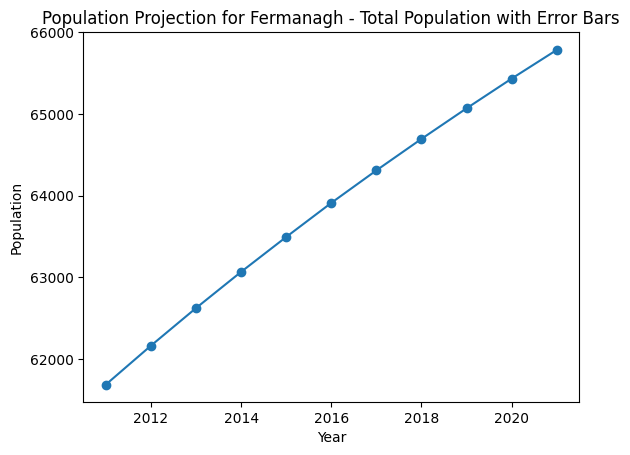

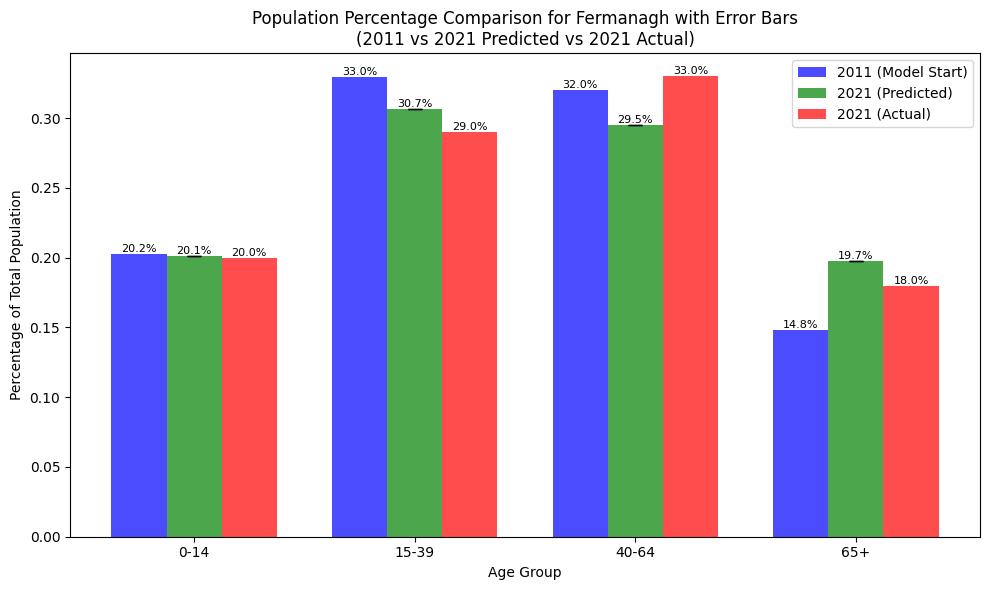

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

def binomial(n,p):
    return np.sum(np.random.random(n) < p)

def xaxis(year):
    x = []
    for i in range(2011, year + 1):
        x.append(i)
    return x

baseYear = 2011
population = 61805
#63585 for Fermanagh and 116812 for Fermanagh and Omagh
populationsBA = population * np.array([0.2,0.33,0.32,0.14])
populationsFBA = populationsBA / 2
deathRates = np.array([0.00025, 0.00070, 0.00421, 0.03582])
migrationRates = np.array([0.0089, -0.0025, 0.0012, -0.0004])
numberOfYearsBA = np.array([15,25,25,10000])

#15-19, 20-24, 25-29, 30-34, 35-39, 40-44
fertileAgeDistribution = np.array([0.1635, 0.1475, 0.1609, 0.1743, 0.1796, 0.1743])
fertilityRates = np.array([0.0043, 0.0363, 0.0950, 0.1495, 0.0948, 0.0205])

def ageSimulationBA(simulatedYear, M):
    difference = simulatedYear + 1 - baseYear
    yearlyPopulation = np.zeros((M, difference, 4))
    yearly_pc_population = np.zeros((M, difference, 4))
    total_populations = np.zeros((M, difference))

    for m in range(M):
        currentPopulationsBA = populationsBA.copy()
        currentPopulationsFBA = populationsFBA.copy()
        current_fertility_rates = fertilityRates.copy()

        for i in range(difference):
            fertilePopulation = currentPopulationsFBA[1] + (currentPopulationsFBA[2] * 0.20)
            fertileAgePopulation = fertileAgeDistribution * fertilePopulation

            births = 0
            for j in range(len(fertileAgePopulation)):
                births += binomial(int(fertileAgePopulation[j]), current_fertility_rates[j])

            agingOut = np.zeros(4)
            deaths = np.zeros(4)
            migrants = np.zeros(4)

            for j in range(4):
                agingOut[j] = currentPopulationsBA[j] / numberOfYearsBA[j]
                deaths[j] = binomial(int(currentPopulationsBA[j]), deathRates[j])
                migrants = currentPopulationsBA * migrationRates

            newPopulations = np.zeros(4)
            newPopulations[0] = currentPopulationsBA[0] + births - agingOut[0] - deaths[0] + migrants[0]
            newPopulations[1] = currentPopulationsBA[1] + agingOut[0] - agingOut[1] - deaths[1] + migrants[1]
            newPopulations[2] = currentPopulationsBA[2] + agingOut[1] - agingOut[2] - deaths[2] + migrants[2]
            newPopulations[3] = currentPopulationsBA[3] + agingOut[2] - deaths[3] + migrants[3]

            currentPopulationsBA = newPopulations
            total_population = np.sum(currentPopulationsBA)
            total_populations[m,i] = total_population
            cp_pc_BA = currentPopulationsBA / total_population
            currentPopulationsFBA = currentPopulationsBA / 2

            yearlyPopulation[m,i] = currentPopulationsBA
            yearly_pc_population[m,i] = cp_pc_BA
            currentYear = baseYear + i
            if 2021 < currentYear < 2028:
              current_fertility_rates = current_fertility_rates * 0.983425

    return yearlyPopulation, yearly_pc_population, total_populations

M = 200
years = xaxis(2021)
populationData = ageSimulationBA(2021, M)

age_group_labels = ['0-14', '15-39', '40-64', '65+']
colors = ['blue', 'green', 'orange', 'red']

means = np.mean(populationData[0], axis=0)
totalsmeans = np.mean(populationData[2], axis=0)
errors = 1.645*np.std(populationData[0], axis=0) / np.sqrt(M)
totalerrors = 1.645*np.std(populationData[2], axis=0) / np.sqrt(M)

for i in range(4):
   plt.errorbar(years, means[:, i], yerr=errors[:, i], fmt='o-', color=colors[i], label=age_group_labels[i])

plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Projection for Fermanagh - All Age Groups with Error Bars')
plt.legend()
plt.savefig('population_projection.png')
plt.show()

percentage_means = np.mean(populationData[1], axis=0)
percentage_errors = 1.645 * np.std(populationData[1], axis=0) / np.sqrt(M)

for i in range(4):
    plt.errorbar(years, percentage_means[:, i], yerr=percentage_errors[:, i],
                 fmt='o-', color=colors[i], label=f'{age_group_labels[i]}')

plt.xlabel('Year')
plt.ylabel('Percentage of Total Population')
plt.title('Population Projection for Fermanagh - Percentage Population with Error Bars')
plt.legend()
plt.show()

plt.errorbar(years, totalsmeans, yerr=totalerrors, fmt='o-')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Projection for Fermanagh - Total Population with Error Bars')
plt.show()

first_percentages = np.mean(populationData[1][:, 0], axis=0)
last_percentages = np.mean(populationData[1][:, -1], axis=0)
actual_2021_percentages = np.array([0.2, 0.29, 0.33, 0.18])

# Calculate errors for predicted 2021
last_percentages_errors = 1.645 * np.std(populationData[1][:, -1], axis=0) / np.sqrt(M)

age_group_labels = ['0-14', '15-39', '40-64', '65+']
percentage_data = np.array([first_percentages, last_percentages, actual_2021_percentages])

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.25
index = np.arange(len(age_group_labels))

# Plot bars with error bars for predicted values
bar1 = ax.bar(index - bar_width, percentage_data[0], bar_width, label='2011 (Model Start)', color='blue', alpha=0.7)
bar2 = ax.bar(index, percentage_data[1], bar_width, label='2021 (Predicted)', color='green', alpha=0.7,
              yerr=last_percentages_errors, capsize=5)
bar3 = ax.bar(index + bar_width, percentage_data[2], bar_width, label='2021 (Actual)', color='red', alpha=0.7)

ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage of Total Population')
ax.set_title('Population Percentage Comparison for Fermanagh with Error Bars\n(2011 vs 2021 Predicted vs 2021 Actual)')
ax.set_xticks(index)
ax.set_xticklabels(age_group_labels)
ax.legend()

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=8)

add_value_labels(bar1)
add_value_labels(bar2)
add_value_labels(bar3)

plt.tight_layout()
plt.show()